# This script computes the cropland area of our NUTS-3 regions based on the high resolution cropland layer map

In [15]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from collections import Counter

from shapely.geometry import box
from shapely import Polygon, MultiPolygon
import glob

import os.path as path
import utils

import shapely
import xarray as xr
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

In [16]:
# load cropland data
crop_type_files = sorted(
    glob.glob(path.join(utils.raw_data_dir, "Crop_Types", "**", "*.tif"))
)

In [17]:
# load nuts shapefile and filter only NUTS level 3
nuts3_boundaries_gdf = gpd.read_file(
    path.join(utils.raw_data_dir, "NUTS_RG_01M_2021_4326.shp")
)
nuts3_boundaries_gdf = nuts3_boundaries_gdf[nuts3_boundaries_gdf["LEVL_CODE"] == 3]

In [18]:
# reproject the nuts3-boundaries to the CRS of the cropland map. It is important to project in this direcition, as
# every pixel in the cropland map is exactly 10x10m, as defined by the crs.
with rasterio.open(crop_type_files[0]) as src:
    raster_crs = src.crs
nuts3_boundaries_gdf = nuts3_boundaries_gdf.to_crs(raster_crs)
assert raster_crs == nuts3_boundaries_gdf.crs

In [19]:
# build an index from all of the tiles in the cropland dataset to allow for computationally efficient analysis later on.
print("building tile index...")
records = []
for i, filepath in enumerate(crop_type_files):
    if i % 100 == 0:
        print(f"processing file {i} of {len(crop_type_files)}")
    with rasterio.open(filepath) as src:
        records.append(
            {
                "path": filepath,
                "geometry": box(*src.bounds),
                "crs": src.crs,
                "bounds": src.bounds,
            }
        )

tile_index = gpd.GeoDataFrame(records, crs=records[0]["crs"])
print("Done.")

building tile index...
processing file 0 of 850
processing file 100 of 850
processing file 200 of 850
processing file 300 of 850
processing file 400 of 850
processing file 500 of 850
processing file 600 of 850
processing file 700 of 850
processing file 800 of 850
Done.


# Sanity check: compute a unified geometry based on all cropland tiles (should look like boxy europe)

<Axes: >

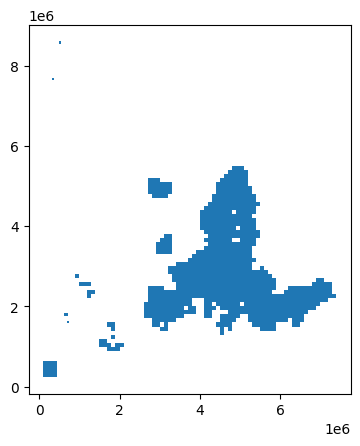

In [20]:
cropmap_boundary = shapely.ops.unary_union(
    [box(*b) for b in tile_index["bounds"].values]
)
poly_is_inside_boundary = nuts3_boundaries_gdf.within(cropmap_boundary)
cropmap_boundary = gpd.GeoDataFrame(geometry=[cropmap_boundary], crs=raster_crs)
cropmap_boundary.plot()

# Sanity check: which NUTS polygons are outside the raster?

- french overseas areas
- the northernmost parts of norway
- UK, which is not covered by the HRL

--> Filter is sensible and can be applied

In [21]:
nuts3_boundaries_gdf[~poly_is_inside_boundary]["NAME_LATN"].values

array(['Guyane', 'Martinique', 'La Réunion', 'Guadeloupe', 'Mayotte',
       'Dumfries & Galloway', 'Gloucestershire', 'Swindon',
       'Cardiff and Vale of Glamorgan', 'Nottingham', 'Durham CC',
       'Northumberland', 'North Nottinghamshire', 'Orkney Islands',
       'Hertfordshire', 'Bedford', 'South Nottinghamshire', 'Leicester',
       'Plymouth', 'South West Wales', 'Swansea',
       'Monmouthshire and Newport', 'Torbay',
       'Greater Manchester South West', 'Greater Manchester South East',
       'Wakefield', 'Derby', 'East Derbyshire',
       'South and West Derbyshire', 'Powys', 'West Cumbria', 'Manchester',
       'Central Bedfordshire', 'Southend-on-Sea', 'Thurrock',
       'Flintshire and Wrexham', 'Gwent Valleys',
       'Bridgend and Neath Port Talbot', 'East Cumbria',
       'Aberdeen City and Aberdeenshire', 'Sunderland', 'Lincolnshire',
       'Herefordshire, County of', 'Greater Manchester North West',
       'Greater Manchester North East', 'Blackburn with Darwe

In [22]:
nuts3_boundaries_gdf = nuts3_boundaries_gdf[poly_is_inside_boundary]
nuts3_boundaries_gdf = nuts3_boundaries_gdf.sort_values(by="NUTS_ID")
nuts3_boundaries_gdf["crop_profile"] = None
country_list = np.unique(nuts3_boundaries_gdf["CNTR_CODE"].values)

In [23]:
def clip_raster(raster_path, geom_list):
    """opens a raster image and returns the value counts of all pixels that lie within a list of Polygons.

    Args:
        raster_path (str): path to a rasterfile that can be read by rasterio (typically geoTIFF)
        geom_list (list(shapely.Polygon)): list of Polygons (representating a Multipolygon) that intersect at least partially with the coordinates in the raster image

    Returns:
        collections.Counter: value counts of all pixels in the raster image that intersect any of the polygons.
    """
    with rasterio.open(raster_path) as src:
        cropped_image, _ = mask(src, geom_list, crop=True)
        values, counts = np.unique(cropped_image, return_counts=True)
        return Counter(dict(zip(values.tolist(), counts.tolist())))

# Compute the cropland area for all NUTS-3 regions - one country at a time

In [ ]:
for cntr_code in country_list:
    if cntr_code.lower() == "uk":
        print("Skipping UK")
        continue  # cropland mask does not exist for UK, any overlap is erroneous.
    
    out_file = path.join(
        utils.intermediate_data_dir, "nuts3_crop_profile", f"{cntr_code}.geojson"
    )
    
    if path.isfile(out_file):
        print(f"Output file for country {cntr_code} already exists ({out_file})")
        print("skipping...")
        continue
    
    print("processing country: ", cntr_code)
    temp_df = nuts3_boundaries_gdf[nuts3_boundaries_gdf["CNTR_CODE"] == cntr_code]

    tile_dict = {}
    tile_data = xr.DataArray()

    # iterate over all NUTS-3 regions
    for row_num, (row_idx, nuts3_row) in enumerate(temp_df.iterrows()):
        if row_num % 25 == 0:
            print(f"processing row {row_num} of {len(temp_df)}")
        geom = nuts3_row.geometry

        # query the tile index to find all overlapping tiles and their corresponding files
        matches = tile_index.sindex.query(geom, predicate="intersects")
        path_list = tile_index.iloc[matches]["path"].values

        global_counter = Counter()
        # unify geometries so all are represented as a list of shapley.Polygon objects
        if isinstance(geom, Polygon):
            geom_list = [geom]
        elif isinstance(geom, MultiPolygon):
            geom_list = list(geom.geoms)
        else:
            raise ValueError("Non-Polygon geometry: ", type(geom))

        # apply the clip_raster function to all geometry lists using parallel processing
        with ThreadPoolExecutor(max_workers=len(path_list)) as executor:
            futures = [
                executor.submit(clip_raster, rasterfile, geom_list)
                for rasterfile in path_list
            ]

            for future in as_completed(futures):
                global_counter += future.result()

        # add the resulting dict as a new column to the dataframe
        temp_df.at[row_idx, "crop_profile"] = dict(global_counter)

    print("writing to file: ", out_file)
    temp_df.to_file(out_file)

processing country:  AL
processing row 0 of 12


/Users/johannesgille/Desktop/CE_2026_4_drought/.venv/lib/python3.9/site-packages/rasterio/features.py:392: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _rasterize(valid_shapes, out, transform, all_touched, merge_alg)


writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/AL.geojson
processing country:  AT
processing row 0 of 35
processing row 25 of 35
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/AT.geojson
processing country:  BE
processing row 0 of 44
processing row 25 of 44
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/BE.geojson
processing country:  BG
processing row 0 of 28
processing row 25 of 28
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/BG.geojson
processing country:  CH
processing row 0 of 26
processing row 25 of 26
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/CH.geojson
processing country:  CY
processing row 0 of 1
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/CY.